In [2]:
import numpy as np
import mat73
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.io

# load datasets
 2025/10/28, MCx set has 5000 samples (batch 2 - 6)

In [3]:
path = "C:\\Users\\Arthur Zhou\\Documents\\DL\\data\\mcx\\mcx_vol_10000\\padded_mcx_10000_single.mat"
vic_mcx_train = scipy.io.loadmat(path)

In [4]:
path = "C:\\Users\\Arthur Zhou\\UHN\\GTx - DalyShare (1)\\ImageData\\DL\\20250924_Arthur\\MCX\\mcx_box_10000\\batch200\\zeropadded_combined_mcx.mat"
art_mcx_train = scipy.io.loadmat(path)

In [ ]:
path = '/mnt/c/Users/Arthur Zhou/Documents/MATLAB/mcx/processed_pattern_mode'
mat_mcx = mat73.loadmat(f'{path}/combined_mcx.mat')


In [8]:
path_dt = '/mnt/c/Users/Arthur Zhou/Documents/DL/data/dt/2025_0114_CSH_10000_fHb_0_5_to_100'
mat_dt = mat73.loadmat(f'{path_dt}/DL_nImages10000.mat')

In [5]:
art_mcx_f = art_mcx_train['F']
art_mcx_op = art_mcx_train['OP']
art_mcx_df = art_mcx_train['DF']
art_mcx_qf = art_mcx_train['QF']

vic_mcx_f = vic_mcx_train['F']
vic_mcx_op = vic_mcx_train['OP']
vic_mcx_df = vic_mcx_train['DF']
vic_mcx_qf = vic_mcx_train['QF']

In [15]:
art_mcx_f.shape, vic_mcx_f.shape

((10000, 101, 101, 6), (10000, 101, 101, 6))

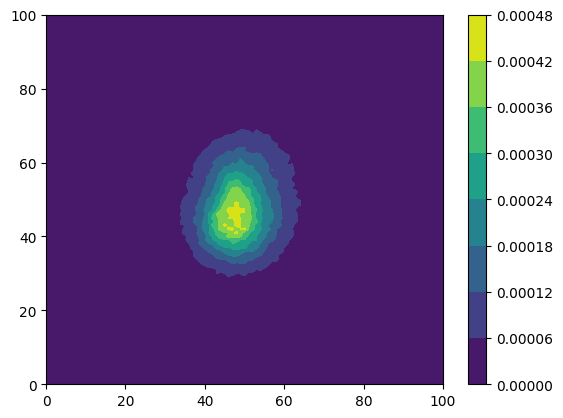

In [16]:
plt.contourf(art_mcx_f[0,:,:,1])
plt.colorbar()

In [ ]:
(art_mcx_f[:,:,:,0] == (art_mcx_f[:,:,:,0].max())).sum()
    
art_mcx_qf.shape

(10000, 101, 101)

In [ ]:
mcx_f = mat_mcx['F']
mcx_op = mat_mcx['OP']
mcx_re = mat_mcx['RE']
mcx_qf = mat_mcx['QF']
mcx_df = mat_mcx['DF']


dt_f = mat_dt['F'][1000:6000,...]
dt_op = mat_dt['OP'][1000:6000,...]
dt_re = mat_dt['RE'][1000:6000,...]
dt_qf = mat_dt['QF'][1000:6000,...]
dt_df = mat_dt['DF'][1000:6000,...]

# vis

In [61]:
def plot_dis(data, data_2 = None, compare=False, label_1 = 'data_1', label_2 ='data_2', cut =False):
    plt.figure(figsize=(6, 3))
    if cut:
        lower = np.percentile(data, 1.0)
        upper = np.percentile(data, 99.0)
        range = (lower, upper)
    else:
        range = None

    plt.hist(data.flatten()[data.flatten() >0 ], bins=40,   density =True, stacked = True, label =label_1, range= range )
    if compare:
        plt.hist(data_2.flatten()[data_2.flatten() >0 ], bins=40, density = True, stacked = True, alpha= 0.5, label = label_2, range= range)
    plt.legend()
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.title('Distribution of Data Values')
    plt.grid(True)


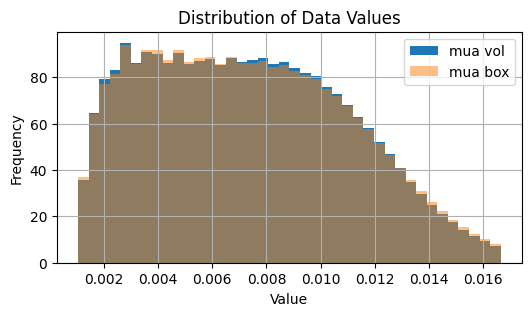

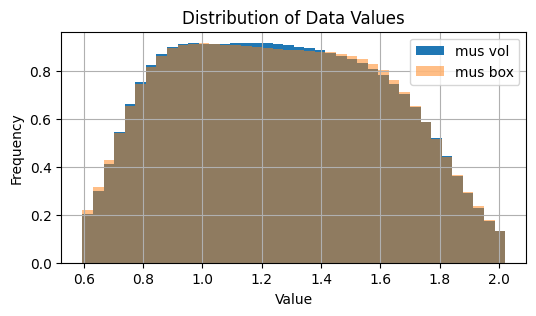

In [54]:
plot_dis(vic_mcx_op[:,:,:,0], art_mcx_op[:,:,:,0], compare = True, label_1 = 'mua vol', label_2 = 'mua box') # mua
plot_dis(vic_mcx_op[:,:,:,1], art_mcx_op[:,:,:,1], compare = True, label_1 = 'mus vol', label_2 = 'mus box') # mus

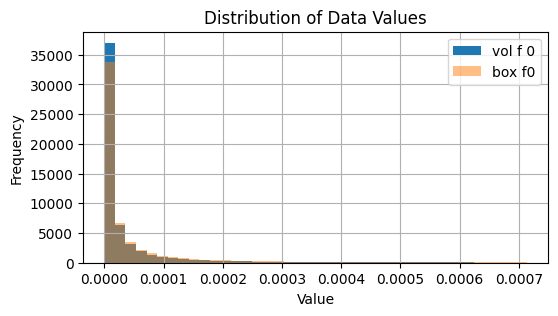

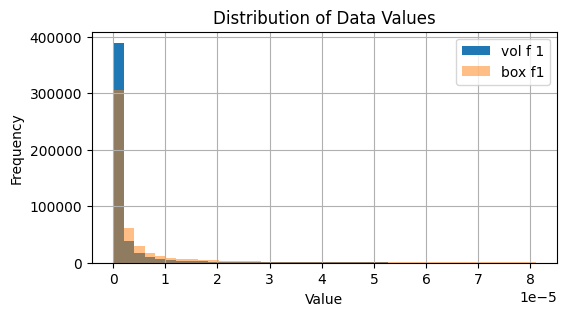

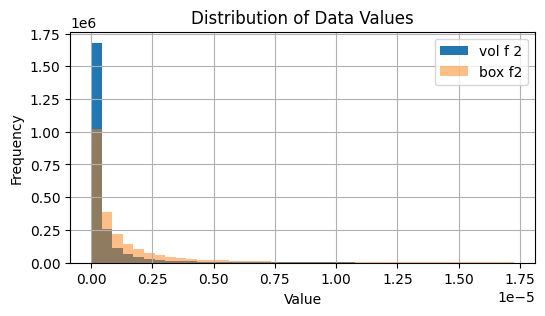

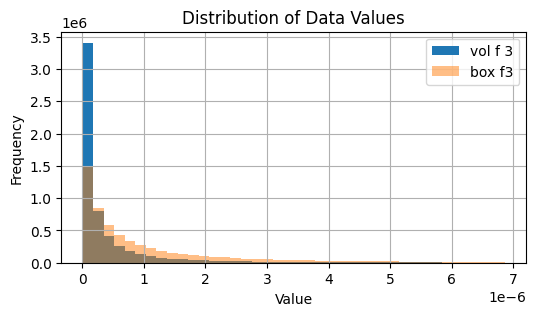

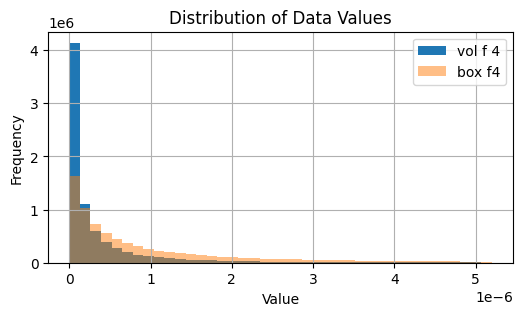

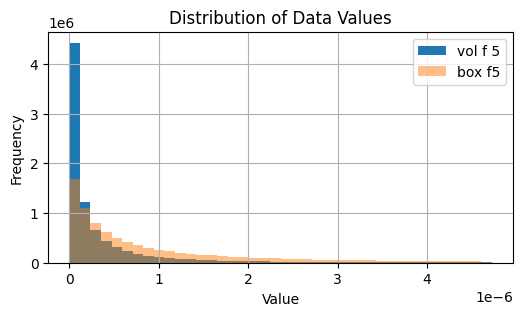

In [55]:
for i in range(vic_mcx_f.shape[-1]):
    plot_dis(vic_mcx_f[:,:,:,i], art_mcx_f[:,:,:,i], compare = True, label_1 = f'vol f {i}', label_2 = f'box f{i}') # mua
#plot_dis(vic_mcx_qf[:,:,:,1], art_mcx_qf[:,:,:,1], compare = True, label_1 = 'vol qf', label_2 = 'box qf') # mus

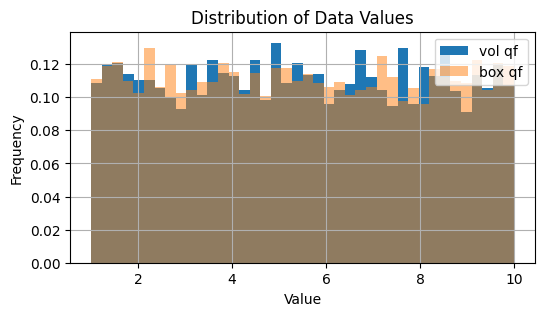

In [63]:
plot_dis(vic_mcx_qf, art_mcx_qf, compare = True, label_1 = "vol qf", label_2 = "box qf", cut = False)

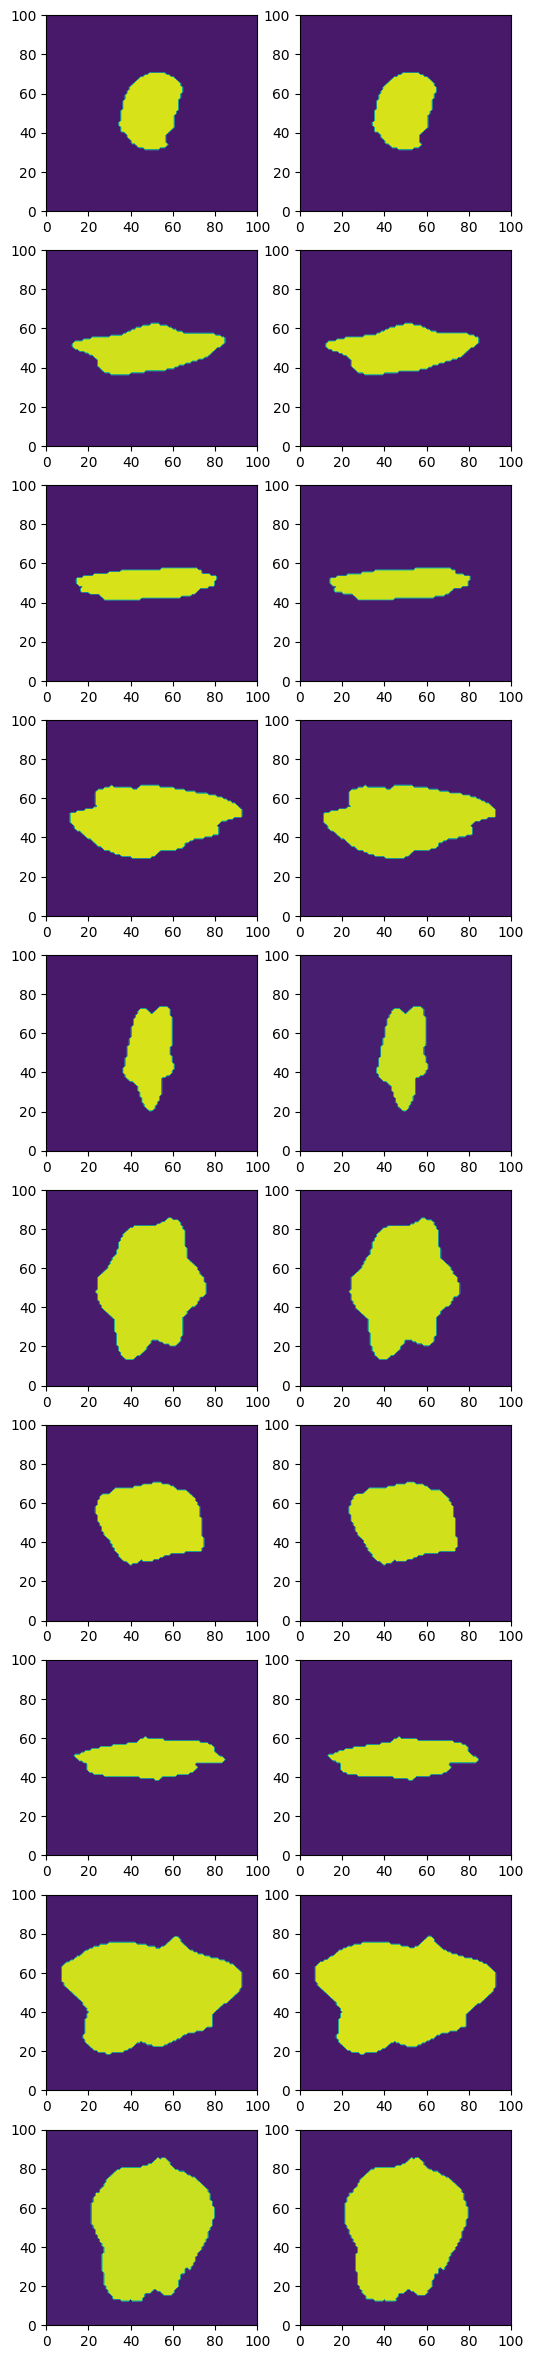

In [42]:
x = 10
fig, ax = plt.subplots(x, 2, figsize=(6, 3*x))

for i in range(x):
    ax[i, 0].contourf(art_mcx_qf[i,...])
    ax[i, 1].contourf(vic_mcx_qf[i,...])

In [6]:

def get_difference_3d(mcx, dt):
    total_difference = []
    for i in range(mcx.shape[0]):
        difference = mcx[i, :, :] - dt[i,:,:]
        total_difference.append(difference)
    return total_difference

In [7]:
def get_difference_3d(mcx, dt):
    total_difference = []
    for i in range(mcx.shape[0]):
        temp = []
        for j in range(mcx.shape[-1]):
            difference = mcx[i, :, :, j] - dt[i, :, :, j]
            temp.append(difference)
        total_difference.append(temp)
    return total_difference


### looking at losses and stuff

lightning_loss = ""

In [2]:
import pandas as pd

In [3]:
lightning_loss ='C:\\Users\\Arthur Zhou\\UHN\\GTx - DalyShare (1)\\ImageData\\DL\\20250924_Arthur\\training_logs\\local_lightning_test_norm_f_20\\loss_norm_f_20\\version_0\\metrics.csv'
light_loss = pd.read_csv(lightning_loss)

In [35]:
vic_loss ="C:\\Users\\Arthur Zhou\\GitHub\\gtx_victor\\code_tf\\model_params\\hikaru_dropout_pad10_noTBR\\loss.log"
vic_loss = pd.read_csv(vic_loss)

In [36]:
vic_loss

,epoch,learning_rate,loss,outDF_mae_df,outDF_tumor_mae,outQF_mae_qf,val_loss,val_outDF_mae_df,val_outDF_tumor_mae,val_outQF_mae_qf
0,0,0.00050,2.711190,2.064972,3.107960,0.646218,3.704467,3.217877,1.866326,0.486590
1,1,0.00050,0.931415,0.496899,1.199936,0.434516,2.935109,2.481974,1.353177,0.453134
2,2,0.00050,0.765581,0.375294,0.978447,0.390287,2.699463,2.231448,1.219475,0.468016
3,3,0.00050,0.708302,0.346697,0.910897,0.361605,1.665464,1.198183,0.929529,0.467281
4,4,0.00050,0.620376,0.280628,0.875634,0.339748,1.087430,0.617451,1.019026,0.469979
5,5,0.00050,0.630865,0.310169,0.868900,0.320697,0.830676,0.329645,1.033168,0.501031
6,6,0.00050,0.556714,0.266291,0.789038,0.290422,0.765373,0.310136,1.186544,0.455237
7,7,0.00050,0.537539,0.255338,0.765021,0.282201,0.815990,0.325461,1.183248,0.490529
8,8,0.00050,0.514512,0.242898,0.739966,0.271614,0.753849,0.317435,1.277637,0.436414
9,9,0.00050,0.468471,0.207744,0.711733,0.260727,0.847473,0.408932,1.058329,0.438541


In [12]:
import matplotlib.pyplot as plt

In [32]:
def plot_loss(light_loss, metric):
    x = light_loss[metric].dropna().values
    y = light_loss['epoch'].unique()
    plt.plot(y, x, label=metric)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

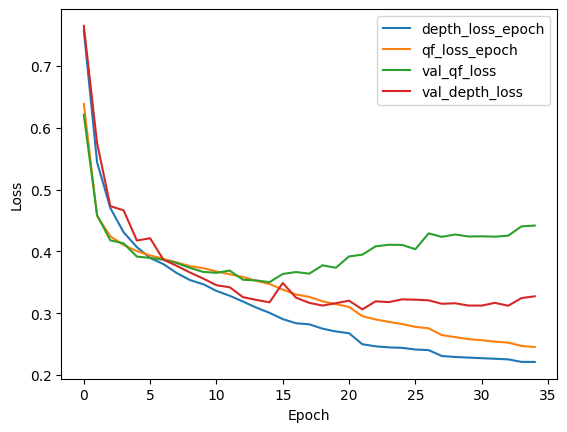

In [ ]:
plot_loss(light_loss, 'depth_loss_epoch')
plot_loss(light_loss, 'qf_loss_epoch')
plot_loss(light_loss, 'val_qf_loss')
plot_loss(light_loss, 'val_depth_loss')


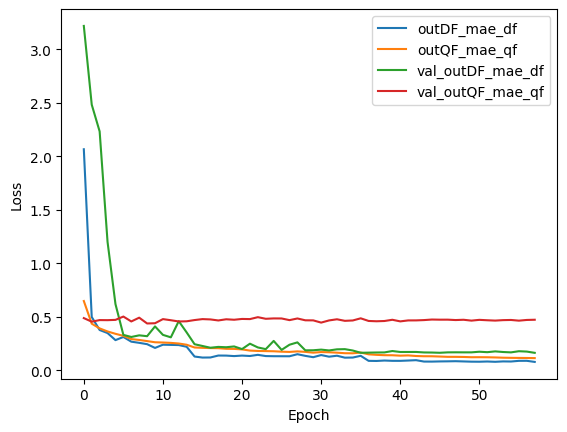

In [37]:
plot_loss(vic_loss, 'outDF_mae_df')
plot_loss(vic_loss, 'outQF_mae_qf')
plot_loss(vic_loss, 'val_outDF_mae_df')
plot_loss(vic_loss, 'val_outQF_mae_qf')